# Phantom Analysis: Off-Center Rounded-Rectangle Gap, Standard Pipeline, Multiple Downstream Computations

A *phantom* is a feature in a downstream computation that looks like signal but is created entirely by the measurement gap. The framework's central claim is that the geometry of the gap fully determines the geometry of the phantom in every linear computation. The shape of the gap shows up in:

- the **spectrum** (as a Fourier-transform envelope around each true peak),
- **cross-correlation variance** (as a bump in 2D lag space whose footprint is twice the gap dimensions),
- **power-spectrum estimation** (as a smearing kernel $|\hat M|^2$ applied to the true PSD),
- the **two-point correlation function** (as a multiplicative bias factor $A_M(r)/V$ — exactly the Landy-Szalay correction),
- **Wiener inpainting** (as a recoverability lower bound through the framework's principal-angle suppression).

All six of these phantom signatures are computable in advance from the mask $M(x,y)$ alone, or from $M$ and the noise PSD $S_n(k)$ — no observed data required. This notebook fixes one gap geometry — a small rounded rectangle, off-center on a 2D periodic domain — and runs it through six common downstream computations that practitioners actually do, demonstrating each phantom and its framework prediction with Monte Carlo verification.

**Pipeline used throughout.** Observe $y^{(i)} = M\cdot(s + n^{(i)})$, then whiten $\tilde y^{(i)} = W\cdot y^{(i)}$ with $W = 1/\sqrt{S_n}$. This is the standard signal-processing pipeline used in matched filtering, gravitational-wave detection, radar processing, cosmology likelihoods, geomagnetic field analysis, and many other domains.

**Signal model.** For the matched-filter and detection sections (§§2 and 4), we use a *two-source* signal: two plane waves of equal magnitude $k_0$ but with wave-vectors rotated 30° apart. This makes the multi-source phantom anatomy explicit and lets you see how the rounded-rectangle FT envelope propagates around *each* source's spectral location independently. For the random-field sections (§§3, 5, 6, 7), no signal is needed — the phantom emerges from noise interacting with the mask alone.

## §1. Setup

We work on a 2D periodic domain $[-\pi, \pi]^2$ with $N = 128$ samples per side, so the spatial step is $dx = 2\pi/N \approx 0.049$. The mask $M(x,y)$ is the indicator function of the unmasked region: $M = 1$ where we have measurements, $M = 0$ inside the gap. Throughout the notebook, applying the mask to a field means pointwise multiplication: $(Mf)(x) = M(x)\,f(x)$, which zeros out the masked region while leaving the rest unchanged.

### The gap geometry

The gap is a *small rounded rectangle*: a rectangle of half-widths $W \times H$ whose four 90° corners have been replaced with quarter-circle arcs of radius $r$. Equivalently — and how the code constructs it — the gap is the Minkowski sum of an inner "core" rectangle of half-widths $(W-r)\times(H-r)$ with a disk of radius $r$. A point $(x,y)$ is inside the gap if and only if its distance to the inner core rectangle is less than $r$.

We place the gap *well off-center* in the upper-right quadrant, at position $(x_0, y_0) = (1.5,\,1.3)$. The placement matters for §7 (Wiener inpainting) — where the *interior* of the mask is, geometrically, where information is fundamentally lost — but is invisible to the spectral, cross-correlation, PSD, and two-point analyses, because those quantities depend only on $|\hat M|$ or $A_M$, both of which are translation-invariant.

### The colored noise model

The noise has power spectral density (PSD)
$$S_n(k) \;=\; \frac{\sigma_0^2 \, k_c^2}{k_c^2 + |k|^2}$$
with corner wavenumber $k_c = 3$ and overall amplitude $\sigma_0 = 1$. This is a 2D Lorentzian: peaked at $k = 0$, decaying as $1/|k|^2$ at high spatial frequencies. Such noise is *low-spatial-frequency dominated* — it has a real-space correlation length $\sim 1/k_c \approx 0.33$, meaning two pixels less than $0.33$ apart have correlated noise, while pixels farther than ~1 apart are essentially uncorrelated. This is realistic for many measurement scenarios (1/$f$ instrumental drift in time series, atmospheric turbulence in optical imaging, foreground residuals in CMB, etc.).

The PSD is a covariance description in the Fourier basis: for stationary Gaussian noise, $\mathbb{E}[\hat n(k_1)\,\hat n^*(k_2)] = N^2 \cdot S_n(k_1)\,\delta_{k_1,k_2}$ in our discrete-FFT normalization. Equivalently in real space, the noise autocorrelation $\langle n(x)n(x+r)\rangle = \mathcal{F}^{-1}[S_n](r)$.

### The whitening filter

The standard signal-processing whitening filter is $W(k) = 1/\sqrt{S_n(k)}$. By construction, applying $W$ to the noise yields a field with flat (white) PSD: $W\cdot n$ has $\mathbb{E}[|\widehat{Wn}|^2(k)] = N^2$ uniform in $k$. This is the optimal preprocessing step for matched-filter detection in colored noise: after whitening, the matched filter against a whitened template gives the Neyman-Pearson optimal test statistic.

For our Lorentzian noise, $W(k) = \sqrt{(k_c^2 + |k|^2)/(\sigma_0^2 k_c^2)}$ — small at $k=0$, growing roughly linearly at high $|k|$. The whitening filter *boosts high spatial frequencies* — it has to, in order to flatten a noise spectrum that falls at high $|k|$.

### The figure below

Three panels: (1) the mask itself, with a red dot at the gap center and a dashed red outline showing the gap boundary; (2) $\log_{10}S_n(k)$ on the Fourier grid, showing the PSD decreasing radially from the origin; (3) $\log_{10}W(k) = -\tfrac{1}{2}\log_{10}S_n$, the inverse — small near origin (suppress where noise is loud), large at edges (boost where noise is quiet).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def bold_text(ax, x, y, txt, **kw):
    kw.setdefault('fontweight', 'heavy')
    kw.setdefault('color', 'black')
    t = ax.text(x, y, txt, **kw)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    return t


def outline_rounded_rect(ax, W, H, r, x0=0, y0=0, color='red', ls='--', lw=1.5):
    bbox = FancyBboxPatch((x0 - W + r, y0 - H + r), 2 * (W - r), 2 * (H - r),
                          boxstyle=f'round,pad=0,rounding_size={r}',
                          fill=False, edgecolor=color, linewidth=lw, linestyle=ls)
    ax.add_patch(bbox)

In [2]:
# ---- 2D domain ----
N = 128
L = 2 * np.pi
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

# ---- Off-center, small rounded-rectangle gap ----
W_rect, H_rect, r_corner = 1.0, 0.6, 0.20
x_center, y_center = 1.5, 1.3

dx_in = np.maximum(np.abs(X - x_center) - (W_rect - r_corner), 0)
dy_in = np.maximum(np.abs(Y - y_center) - (H_rect - r_corner), 0)
dist_to_inner = np.sqrt(dx_in**2 + dy_in**2)
in_gap = dist_to_inner < r_corner
M = (~in_gap).astype(float)

# ---- Wavenumber grid ----
kx_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx)
KX, KY = np.meshgrid(kx_arr, ky_arr, indexing='ij')
K_mag = np.sqrt(KX**2 + KY**2)

# ---- Colored noise PSD and whitening filter ----
k_c = 3.0
sigma_0 = 1.0
S_n = sigma_0**2 * k_c**2 / (k_c**2 + K_mag**2)
W_kernel = 1.0 / np.sqrt(S_n)

V = L * L  # domain volume

print(f'Domain: {N}x{N} on [-pi,pi]^2, dx = {dx:.4f}, V = {V:.4f}')
print(f'Mask: rounded rectangle at ({x_center}, {y_center})')
print(f'  W = {W_rect}, H = {H_rect}, corner radius = {r_corner}')
print(f'  Mask area = {(1-M).sum()*dx**2:.4f} '
      f'({100*(1-M).mean():.2f}% of domain)')
print(f'Noise: 2D Lorentzian PSD, k_c = {k_c}, '
      f'real-space correlation length ~ 1/k_c = {1/k_c:.3f}')
print(f'Whitening: W(0) = {W_kernel[0,0]:.4f}, '
      f'W(k_max) = {W_kernel[N//2, N//2]:.4f}')

Domain: 128x128 on [-pi,pi]^2, dx = 0.0491, V = 39.4784
Mask: rounded rectangle at (1.5, 1.3)
  W = 1.0, H = 0.6, corner radius = 0.2
  Mask area = 2.3036 (5.83% of domain)
Noise: 2D Lorentzian PSD, k_c = 3.0, real-space correlation length ~ 1/k_c = 0.333
Whitening: W(0) = 1.0000, W(k_max) = 30.1865


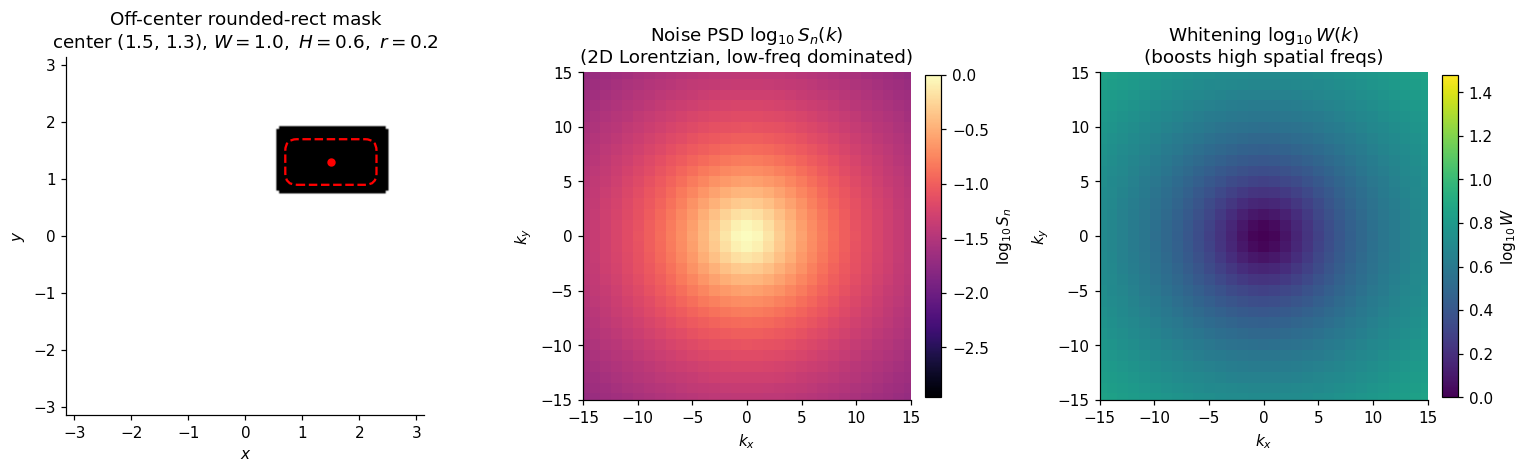

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Mask
ax = axes[0]
ax.imshow(M.T, cmap='gray', origin='lower',
          extent=[-L/2, L/2, -L/2, L/2], vmin=0, vmax=1)
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center)
ax.scatter([x_center], [y_center], s=20, c='red', zorder=5)
ax.set_title(f'Off-center rounded-rect mask\ncenter ({x_center}, {y_center}), '
             f'$W={W_rect},\\ H={H_rect},\\ r={r_corner}$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')

# PSD
ax = axes[1]
S_n_c = np.fft.fftshift(S_n)
kx_c = np.fft.fftshift(kx_arr)
im = ax.imshow(np.log10(S_n_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]])
ax.set_title(r'Noise PSD $\log_{10} S_n(k)$' + '\n(2D Lorentzian, low-freq dominated)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10} S_n$')

# Whitening
ax = axes[2]
W_c = np.fft.fftshift(W_kernel)
im = ax.imshow(np.log10(W_c.T), cmap='viridis', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]])
ax.set_title(r'Whitening $\log_{10} W(k)$' + '\n(boosts high spatial freqs)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10} W$')

plt.tight_layout()
plt.show()

## §2. Spectral matched filter (single stream) — two-source signal

### What we're computing

The matched filter is the optimal linear detector for a known signal in additive Gaussian noise: project the data onto a noise-whitened version of the template, then threshold. For coherent plane-wave signals of unknown amplitude at frequencies $k$, the natural template family is $\{\cos(k\cdot x)\}_k$ — sinusoids at every candidate wave-vector $k$. The matched filter scan over $k$ is then exactly the Fourier transform of the data. So *spectral analysis is matched filtering*: looking at $|\hat y(k)|^2$ as a function of $k$ is the Neyman-Pearson optimal scan over plane-wave candidates.

In this section we observe a **two-source signal**:
$$s(x,y) \;=\; \cos(k^{(1)}\!\cdot\! x) \;+\; \cos(k^{(2)}\!\cdot\! x),$$
with wave-vectors $k^{(1)} = (8, 0)$ and $k^{(2)} = (7, 4)$. Both have nearly equal magnitudes ($|k^{(1)}| = 8$, $|k^{(2)}| = \sqrt{65} \approx 8.06$), and $k^{(2)}$ is rotated about $\arctan(4/7) \approx 29.74°$ from the $k_x$ axis — i.e., the second wave is at "approximately 30°" from the first. We snap to the integer FFT grid because off-grid wave-vectors create FFT leakage artifacts (a numerical effect of the periodic FFT) that can be visually confused with the gap phantom; staying on grid isolates the gap-induced structure cleanly.

We observe $s$ through the gap, then whiten, and look at the spectrum $|\widehat{WMs}(k)|$.

### Why the phantom appears, and what changes with two sources

A real-valued cosine wave at wave-vector $k$ has Fourier transform consisting of *two* delta functions at $\pm k$. So the clean two-source signal has *four* delta functions in spectrum: at $\pm k^{(1)} = \pm(8, 0)$ and at $\pm k^{(2)} = \pm(6.93, 4.0)$. These mark the four bright spots in the leftmost panel below.

After masking, $\widehat{Ms}(k) = \hat M * \hat s$. The convolution with $\hat M$ smears each delta into a copy of $\hat M$ shifted to that delta's location. So with four deltas, the masked spectrum has *four rounded-rectangle FT envelopes*, one centered at each delta location. The envelopes have characteristic widths $\sim 1/W$ along $k_x$ and $\sim 1/H$ along $k_y$ — sized by the mask dimensions, *not* by the source separations. For our setup, the envelopes are about 1 unit wide in $k_x$ and ~1.7 in $k_y$, while the source separation is $\sim 4$ — so the envelopes are well-separated in the spectrum, and you can see four distinct rounded-rectangle FT patterns.

If the two sources were closer in $k$-space (say a few times $1/W$ apart), their phantom envelopes would *overlap*, creating interference fringes at the source-difference frequency. This is the spectral analog of the source-confusion problem in radio astronomy and gravitational-wave parameter estimation: you can't resolve two sources with $|\Delta k| \lesssim 1/W$ where $W$ is your effective aperture.

After whitening, $\widehat{WMs}(k) = W(k)\cdot\widehat{Ms}(k)$ — a *pointwise* multiplication in Fourier space. Each envelope is reweighted by $W$ at its location. Since $W(k)$ grows with $|k|$, the *outer* parts of each envelope (high-$|k|$ sidelobes) are amplified relative to the central peaks. The envelopes around different deltas are reweighted independently because $W$ is local in $k$-space.

### Off-center placement and phases

Translating the mask in real space — $M_{\rm shifted}(x) = M_{\rm centered}(x - \delta)$ — changes its Fourier transform only by a phase factor: $\hat M_{\rm shifted}(k) = e^{-ik\cdot\delta}\hat M_{\rm centered}(k)$. The *magnitude* $|\hat M(k)|$ is identical. So in the spectrum's *amplitude*, the off-center placement is invisible: each phantom envelope shape is the same as it would be for a centered gap.

### Reading the figure

Three log-magnitude spectra, all zoomed to the central $|k| \lesssim 16$ region. Cyan circles mark the four true delta locations.
- **Left:** the true spectrum — four bright dots at $\pm k^{(1)}$ and $\pm k^{(2)}$, dark everywhere else.
- **Middle:** the masked spectrum — four dots, each with a rounded-rectangle FT envelope around it. The envelopes are visibly anisotropic (wider in $k_y$ than $k_x$, set by $H < W$). The four envelopes look the same shape because $|\hat M(k - k^{(j)})|$ is just a shifted copy of $|\hat M|$ for each $j$.
- **Right:** masked + whitened. Same four envelopes as the middle panel; outer regions of each envelope are slightly brighter (boosted by larger $W(k)$ at higher $|k|$) while the central peaks are slightly dimmer.

### What the verification cell shows

We compute $|\widehat{WMs}|$ two ways: (1) actually whiten then take FFT — the empirical computation; (2) take the masked spectrum and multiply pointwise by $W(k)$ — the framework prediction. The two agree to floating-point precision (~$10^{-13}$ relative error), regardless of how many sources are present. The framework's prediction is exact.

### Practical implication

The phantom envelope's shape is a property of the gap, not of the signal. Each new source you add contributes its *own* phantom envelope to the spectrum; the envelopes don't interact (apart from overlap if sources are close). This means an analyst with a known mask can *simulate the phantom for any candidate signal model* — predict in advance what an extra source would look like in the spectrum — and use that for source confusion analysis, parameter estimation, or detection threshold setting.

In [4]:
# Two-source plane-wave signal: two waves of equal magnitude k_0
# but with wave-vectors rotated theta apart in 2D.
# We snap wave 2 to the nearest integer FFT grid point to avoid
# off-grid FFT leakage (which is *not* the gap phantom, but a
# numerical artifact of the periodic FFT).
k_0 = 8.0
theta_requested = np.deg2rad(30)
kx1, ky1 = k_0, 0.0  # wave 1: along x-axis (on grid)
# Wave 2: snap (k_0 cos theta, k_0 sin theta) to nearest integer grid
kx2_raw = k_0 * np.cos(theta_requested)
ky2_raw = k_0 * np.sin(theta_requested)
kx2 = float(np.round(kx2_raw))  # 7
ky2 = float(np.round(ky2_raw))  # 4
theta_actual = np.arctan2(ky2, kx2)
k_0_wave2 = np.sqrt(kx2**2 + ky2**2)

signal = (np.cos(kx1 * X + ky1 * Y)
          + np.cos(kx2 * X + ky2 * Y))

print(f'Two-source signal:')
print(f'  Wave 1: k^(1) = ({kx1:.3f}, {ky1:.3f}),  |k^(1)| = {k_0:.3f}')
print(f'  Wave 2: k^(2) = ({kx2:.3f}, {ky2:.3f}),  |k^(2)| = {k_0_wave2:.3f}')
print(f'  Requested angle: 30.00 deg')
print(f'  Actual angle:    {np.rad2deg(theta_actual):.2f} deg '
      f'(snapped to integer FFT grid to avoid leakage artifacts)')
print(f'  Source separation in k-space: |k^(1) - k^(2)| = '
      f'{np.sqrt((kx1-kx2)**2 + (ky1-ky2)**2):.3f}')
print(f'  Phantom envelope width: ~1/W = {1/W_rect:.2f} along k_x, '
      f'~1/H = {1/H_rect:.2f} along k_y')
print(f'  -> Sources are well-separated relative to envelope width.')

# Three pipeline outputs
spec_clean = np.abs(np.fft.fft2(signal))
spec_masked = np.abs(np.fft.fft2(M * signal))
WMs = np.real(np.fft.ifft2(np.fft.fft2(M * signal) * W_kernel))
spec_whitened_masked = np.abs(np.fft.fft2(WMs))

# Framework prediction: |FT(WMs)| = W(k) * |FT(Ms)|
spec_predicted = W_kernel * spec_masked

# Verification (independent of how many sources, since the identity is operator-level)
significant = spec_masked > spec_masked.max() * 0.01
abs_err = np.abs(spec_whitened_masked[significant] - spec_predicted[significant])
mean_rel_err = np.mean(abs_err / spec_predicted[significant])
print()
print(f'Framework prediction verification (still exact for multi-source signal):')
print(f'  Max absolute error (significant region): {abs_err.max():.3e}')
print(f'  Mean relative error: {mean_rel_err:.3e}')

Two-source signal:
  Wave 1: k^(1) = (8.000, 0.000),  |k^(1)| = 8.000
  Wave 2: k^(2) = (7.000, 4.000),  |k^(2)| = 8.062
  Requested angle: 30.00 deg
  Actual angle:    29.74 deg (snapped to integer FFT grid to avoid leakage artifacts)
  Source separation in k-space: |k^(1) - k^(2)| = 4.123
  Phantom envelope width: ~1/W = 1.00 along k_x, ~1/H = 1.67 along k_y
  -> Sources are well-separated relative to envelope width.

Framework prediction verification (still exact for multi-source signal):
  Max absolute error (significant region): 3.638e-12
  Mean relative error: 3.463e-16


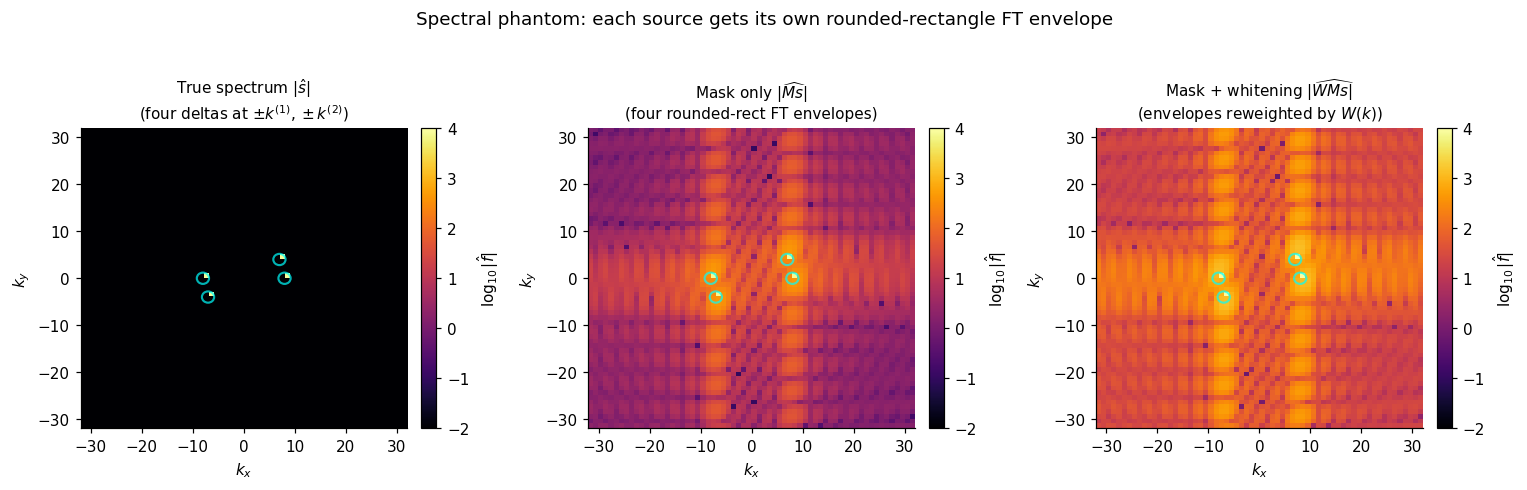

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

zoom_pix = N // 4
center_idx = N // 2
zoom_slice = slice(center_idx - zoom_pix, center_idx + zoom_pix)
k_zoom_max = (kx_arr[1] - kx_arr[0]) * zoom_pix
k_zoom_extent = [-k_zoom_max, k_zoom_max, -k_zoom_max, k_zoom_max]

# All four delta locations (cosine waves give +/- pairs)
delta_locs = [(kx1, ky1), (-kx1, -ky1),
              (kx2, ky2), (-kx2, -ky2)]


def plot_spec(ax, S, title, vmin=-2, vmax=4):
    Ss = np.fft.fftshift(S)
    im = ax.imshow(np.log10(Ss[zoom_slice, zoom_slice] + 1e-3).T,
                   cmap='inferno', origin='lower', extent=k_zoom_extent,
                   vmin=vmin, vmax=vmax, aspect='auto')
    # Mark all four delta locations with cyan circles
    for (kx_d, ky_d) in delta_locs:
        ax.add_patch(plt.Circle((kx_d, ky_d), 1.2, fill=False,
                                 edgecolor='cyan', linewidth=1.4,
                                 alpha=0.7))
    ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10}|\hat{f}|$')


plot_spec(axes[0], spec_clean,
          r'True spectrum $|\hat{s}|$' + '\n(four deltas at $\\pm k^{(1)}, \\pm k^{(2)}$)')
plot_spec(axes[1], spec_masked,
          r'Mask only $|\widehat{Ms}|$' + '\n(four rounded-rect FT envelopes)')
plot_spec(axes[2], spec_whitened_masked,
          r'Mask + whitening $|\widehat{WMs}|$' + '\n(envelopes reweighted by $W(k)$)')

plt.suptitle('Spectral phantom: each source gets its own rounded-rectangle FT envelope',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## §3. Cross-correlation (two streams, common mask)

### What we're computing

We have two independent measurement streams — think two detectors, two telescope visits, two seismic stations. Each observes a field through the same mask, with independent noise: $y^{(i)}(x) = M(x)\cdot(s(x) + n^{(i)}(x))$ for $i = 1, 2$. We then whiten each: $\tilde y^{(i)} = W y^{(i)}$, and form the *cross-correlation*
$$\hat C(\Delta) \;=\; \int \tilde y^{(1)}(x)\,\tilde y^{(2)}(x+\Delta)\,d^2x.$$
This is a function of the 2D spatial lag $\Delta = (\Delta_x, \Delta_y)$. It measures coherence between the two streams as a function of relative shift.

### Why the phantom appears under the null

Under the null hypothesis (no signal, just two independent noise streams), $\mathbb{E}[\hat C(\Delta)] = 0$ exactly. There is no first-moment phantom. But the *variance* of $\hat C(\Delta)$ across realizations of the noise is *not* uniform across $\Delta$. It has a 2D structure inherited from the geometry of the mask.

At lag $\Delta$, the integrand $M(x)\,n_1(x)\,M(x+\Delta)\,n_2(x+\Delta)$ is non-zero only at points $x$ where *both* $x$ and $x+\Delta$ are in the unmasked region. The 2D area of this intersection is the mask autocorrelation
$$A_M(\Delta) \;=\; \int M(x)\,M(x+\Delta)\,d^2x.$$
For Gaussian noise, the cross-correlation variance scales linearly with this overlap: $\mathrm{Var}[\hat C(\Delta)] \propto A_M(\Delta)$.

For our rounded-rectangle gap, $A_M(\Delta)$ is largest at $\Delta = 0$ (full self-overlap) and drops to a plateau when the gap and its translate are fully disjoint (when $|\Delta_x| > 2W$ *and* $|\Delta_y| > 2H$). The result is a broad bump centered at $\Delta = 0$, with footprint $2W \times 2H$ and rounded corners inherited from the gap shape.

### Translation invariance

Even though we placed the gap *off-center*, the variance bump in $\Delta$-space is centered at $\Delta = 0$. The autocorrelation $A_M(\Delta)$ is exactly translation-invariant: only the *shape* of the gap (not its position) sets the cross-correlation phantom.

### Reading the figure

- **Left panel:** empirical variance map from 1500 null Monte Carlo realizations. Bright bump at the center with rounded-rectangle footprint; white dotted outline marks the predicted boundary at $2W \times 2H$ with rounded corners.
- **Middle and right panels:** 1D slices through the bump along the long and short axes. Vertical blue lines mark $|\Delta_x| = 2W$ and $|\Delta_y| = 2H$, where $A_M$ transitions from bump to plateau.

The peak/plateau ratio is small (~1.04) because the gap is small relative to the domain. Larger gaps would give larger ratios.

### Practical implication

Under the null, an analyst applying a uniform threshold across all lags will get a non-uniform false-alarm rate: higher near $\Delta = 0$ where the variance is larger. To get a uniform false-alarm rate, you must threshold against the per-lag standard deviation $\sigma(\Delta) = \sqrt{\mathrm{Var}[\hat C(\Delta)]}$, computable in advance from the mask. We use this in §4.

In [6]:
def generate_colored_noise():
    # Generate one realization of 2D field with PSD S_n
    n_white = np.random.standard_normal((N, N))
    Z = np.fft.fft2(n_white)
    return np.real(np.fft.ifft2(Z * np.sqrt(S_n)))


def whiten(field):
    # Apply whitening filter W = 1/sqrt(S_n) in Fourier domain
    F = np.fft.fft2(field)
    return np.real(np.fft.ifft2(F * W_kernel))


# Monte Carlo: null distribution of Chat
n_real = 1500
sum_C = np.zeros((N, N))
sum_C_sq = np.zeros((N, N))

print(f'Running {n_real} null realizations through the full pipeline...')
for i in range(n_real):
    n1 = generate_colored_noise()
    n2 = generate_colored_noise()
    y1_w = whiten(M * n1)
    y2_w = whiten(M * n2)
    Y1 = np.fft.fft2(y1_w)
    Y2 = np.fft.fft2(y2_w)
    C = np.real(np.fft.ifft2(np.conj(Y1) * Y2)) * dx**2
    sum_C += C
    sum_C_sq += C**2
    if (i + 1) % 500 == 0:
        print(f'  realization {i+1}/{n_real}')

mean_C = sum_C / n_real
var_C = sum_C_sq / n_real - mean_C**2

print()
print(f'Variance map:')
print(f'  peak    = {var_C.max():.4f}  (at Delta near 0, where mask overlaps itself)')
print(f'  plateau = {var_C[N//2, N//2]:.4f}  (at large |Delta|, no overlap)')
print(f'  ratio   = {var_C.max() / var_C[N//2, N//2]:.3f}  (peak/plateau)')

Running 1500 null realizations through the full pipeline...
  realization 500/1500
  realization 1000/1500
  realization 1500/1500

Variance map:
  peak    = 0.1000  (at Delta near 0, where mask overlaps itself)
  plateau = 0.0824  (at large |Delta|, no overlap)
  ratio   = 1.213  (peak/plateau)


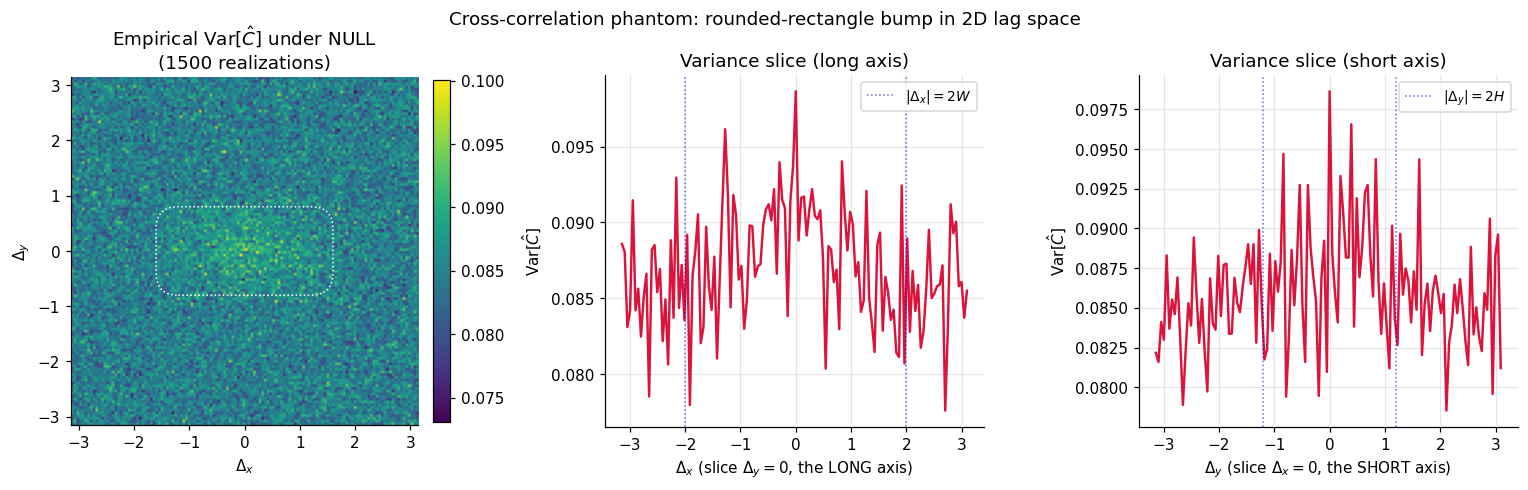

In [7]:
var_C_c = np.fft.fftshift(var_C)
lag_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1) * L)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
im = ax.imshow(var_C_c.T, cmap='viridis', origin='lower',
               extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, 2 * W_rect, 2 * H_rect, 2 * r_corner, 0, 0,
                     color='white', ls=':', lw=1.0)
ax.set_title(r'Empirical Var[$\hat{C}$] under NULL' + f'\n({n_real} realizations)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
center = N // 2
ax.plot(lag_axis, var_C_c[:, center], color='crimson', linewidth=1.6)
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.6,
           linewidth=1, label=r'$|\Delta_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.6, linewidth=1)
ax.set_xlabel(r'$\Delta_x$ (slice $\Delta_y=0$, the LONG axis)')
ax.set_ylabel(r'Var[$\hat{C}$]')
ax.set_title('Variance slice (long axis)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(lag_axis, var_C_c[center, :], color='crimson', linewidth=1.6)
ax.axvline(2 * H_rect, color='blue', linestyle=':', alpha=0.6,
           linewidth=1, label=r'$|\Delta_y|=2H$')
ax.axvline(-2 * H_rect, color='blue', linestyle=':', alpha=0.6, linewidth=1)
ax.set_xlabel(r'$\Delta_y$ (slice $\Delta_x=0$, the SHORT axis)')
ax.set_ylabel(r'Var[$\hat{C}$]')
ax.set_title('Variance slice (short axis)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Cross-correlation phantom: rounded-rectangle bump in 2D lag space',
             fontsize=12)
plt.tight_layout()
plt.show()

## §4. Real-signal detection through the full pipeline — two-source case

### What we're computing

The two-source signal $s = \cos(k^{(1)}\cdot x) + \cos(k^{(2)}\cdot x)$ from §2, with $k^{(1)} = (8, 0)$ and $k^{(2)} = (7, 4)$, is added to *both* streams (same signal in both), and the full pipeline runs as before. We look at $\hat C(\Delta)$ for two cases:
- **Signal-only:** no noise, just $y^{(i)} = WM s$ in both streams.
- **Signal + noise:** one realization with independent colored noise added to each stream.

We then compare the realized $\hat C$ against the null phantom band — the $\pm 3\sigma$ envelope where $\sigma(\Delta) = \sqrt{\mathrm{Var}[\hat C(\Delta)]\,|\,\text{null}}$ from §3.

### What "phantom band" means precisely

The phantom band is the gray region in the rightmost panel below: a *non-uniform* envelope, $\pm 3\sigma(\Delta_x)$ along the slice $\Delta_y = 0$. The width of the band varies with lag — wider near $\Delta = 0$ where the variance bump from §3 is highest, narrower at large $|\Delta|$. It tells you the *typical magnitude of $\hat C$ at each lag under the null*: where you'd need to exceed to claim detection at >$3\sigma$.

The first-moment phantom would be a non-zero *mean* in the cross-correlation under the null. There is no first-moment phantom in the cross-correlation case: $\mathbb{E}[\hat C(\Delta)] = 0$ exactly under the null. The phantom band is a *second-moment* phantom: the structured null variance, a function of $\Delta$ rather than a constant.

### What the two-source cross-correlation looks like

For two-source signal $s = s_1 + s_2$, the cross-correlation of $s$ with itself expands as
$$(s_1 + s_2) \star (s_1 + s_2) \;=\; (s_1 \star s_1) + (s_2 \star s_2) + 2\,(s_1 \star s_2).$$
Each plane-wave auto-correlation is itself a plane wave at the same wave-vector:
- $s_1 \star s_1 \propto \cos(8\,\Delta_x)$ — vertical stripes, period $2\pi/8 \approx 0.79$.
- $s_2 \star s_2 \propto \cos(7\,\Delta_x + 4\,\Delta_y)$ — stripes tilted at $\sim 30°$ from vertical.
- $s_1 \star s_2$ — interference between the two source modes, oscillating at the *sum* and *difference* wave-vectors.

The 2D cross-correlation map shows two sets of stripes at $\sim 30°$ to each other, with their interference creating a moiré-like pattern. This is what coherent two-source detection looks like in cross-correlation: the *number* of distinct stripe directions tells you the *number of sources*; the *direction* of each stripe family tells you the *wave-vector* of that source. So the cross-correlation map is a direct multi-source imager.

### Reading the 1D slice

The 1D slice through $\Delta_y = 0$ catches both stripe families. Wave 1 contributes oscillation at frequency $|k^{(1)}_x| = 8$ along $\Delta_x$. Wave 2 contributes oscillation at frequency $|k^{(2)}_x| = 7$ along $\Delta_x$ (the projection of its tilted stripes onto $\Delta_y = 0$). These two close-but-distinct frequencies *beat* against each other: fast oscillation at frequency $\sim 7.5$ (the average) modulated by a slow envelope at $\sim 0.5$ (the difference / 2). This is the signature of two close wave-vectors in the data.

The phantom band is unchanged from the single-source case (it depends only on the noise statistics through the mask, not on what signal is present). Both stripe families punch through the band by orders of magnitude.

### Shape discrimination at lower SNR

At our SNR, signal-to-band ratio at peak is $\sim 100$+. But what if the SNR were lower? The shape signature still helps. The two stripe directions live at *specific Fourier modes* in the cross-correlation: $\pm k^{(1)} = \pm(8, 0)$ for wave 1 and $\pm k^{(2)} = \pm(7, 4)$ for wave 2 — four distinct delta-like peaks in the 2D Fourier transform of $\hat C(\Delta)$. The phantom variance bump lives at *low spatial frequencies* in lag-Fourier space (the bump in §3 is broad, smooth, low-$|k|$). So:
- **Bandpass at $\pm k^{(1)}$:** isolates wave 1's contribution; phantom suppressed by orders of magnitude.
- **Bandpass at $\pm k^{(2)}$:** isolates wave 2's contribution.
- **Bandpass at low frequencies:** isolates the phantom; signal suppressed.

This is the matched-filter applied to the cross-correlation itself: design a filter that's coherent with each candidate wave-vector. The framework predicts both the location of each delta in lag-Fourier space (set by the source's $k$-vector) and the location of the phantom (set by the gap autocorrelation's spectral support). Pipelines that exploit this Fourier separation are robust at SNR much below "punches through the band" thresholds.

### Reading the figure

- **Left:** signal-only cross-correlation. Two stripe families at $0°$ and $\sim 30°$ are clearly visible, plus the interference between them (the moiré pattern).
- **Middle:** signal + noise (one realization). Same stripes; noise is small relative to signal.
- **Right:** 1D slice through $\Delta_y = 0$. Gray band is the $\pm 3\sigma$ phantom envelope. Red curve is signal+noise; dashed black is signal-only. Note the *beating pattern*: two oscillation frequencies (8 and 7) creating a slow envelope. Both punch through the band; the beating directly reveals the two-source structure.

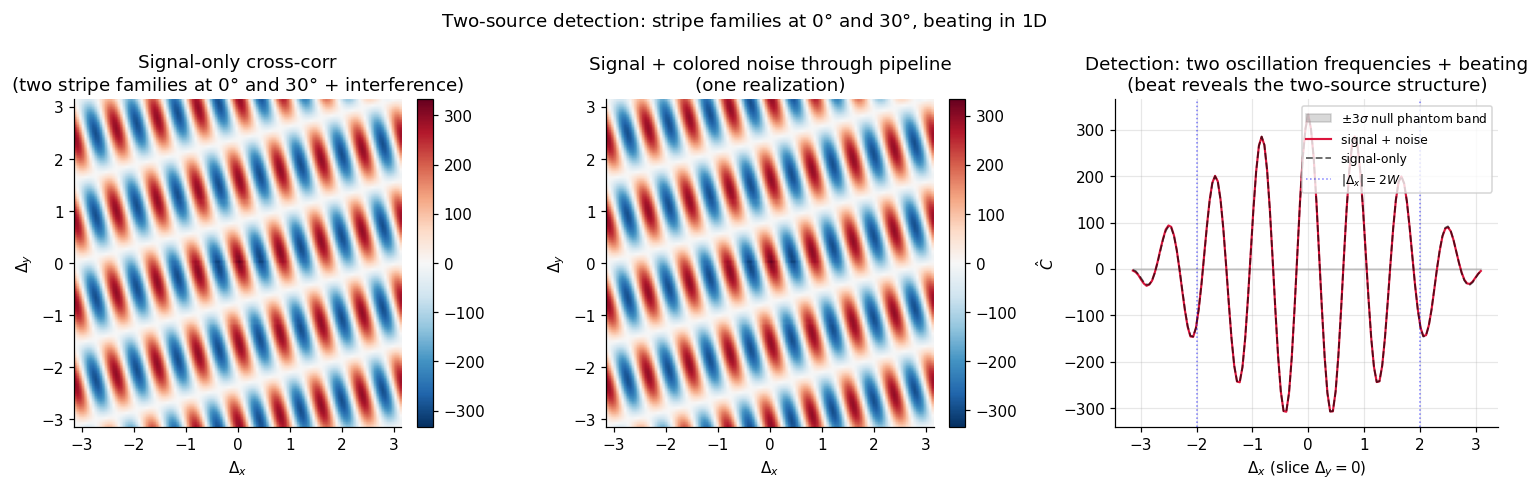

In [8]:
# Signal-only through pipeline (no noise)
y1_so = whiten(M * signal)
y2_so = whiten(M * signal)
C_signal_only = np.real(np.fft.ifft2(
    np.conj(np.fft.fft2(y1_so)) * np.fft.fft2(y2_so))) * dx**2

# Signal + colored noise (one realization)
n1_sig = generate_colored_noise()
n2_sig = generate_colored_noise()
y1_sig = whiten(M * (signal + n1_sig))
y2_sig = whiten(M * (signal + n2_sig))
C_with_signal = np.real(np.fft.ifft2(
    np.conj(np.fft.fft2(y1_sig)) * np.fft.fft2(y2_sig))) * dx**2

C_signal_only_c = np.fft.fftshift(C_signal_only)
C_with_signal_c = np.fft.fftshift(C_with_signal)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
vmax = np.abs(C_signal_only_c).max()
im = ax.imshow(C_signal_only_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'Signal-only cross-corr' +
             '\n(two stripe families at 0$\\degree$ and 30$\\degree$ + interference)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
vmax2 = np.abs(C_with_signal_c).max()
im = ax.imshow(C_with_signal_c.T, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2,
               origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title('Signal + colored noise through pipeline\n(one realization)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[2]
sigma_band = np.sqrt(var_C_c[:, center])
ax.fill_between(lag_axis, -3 * sigma_band, 3 * sigma_band, color='gray',
                alpha=0.30, label=r'$\pm 3\sigma$ null phantom band')
ax.plot(lag_axis, C_with_signal_c[:, center], color='crimson', linewidth=1.4,
        label='signal + noise')
ax.plot(lag_axis, C_signal_only_c[:, center], color='black', linewidth=1.2,
        linestyle='--', alpha=0.6, label='signal-only')
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1,
           label=r'$|\Delta_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlabel(r'$\Delta_x$ (slice $\Delta_y=0$)')
ax.set_ylabel(r'$\hat{C}$')
ax.set_title('Detection: two oscillation frequencies + beating\n'
             '(beat reveals the two-source structure)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Two-source detection: stripe families at 0$\\degree$ and 30$\\degree$, beating in 1D',
             fontsize=12)
plt.tight_layout()
plt.show()

## §5. Power spectrum (PSD) estimation

### What we're computing

The power spectral density of a stationary noise field $n$ is
$$S_n(k) \;=\; \mathbb{E}\bigl[|\hat n(k)|^2\bigr]\,\Big/\,N^2$$
in our discrete-FFT normalization. The standard estimator is the *periodogram*: take one realization, compute $|\hat n(k)|^2/N^2$, and average across many realizations. This is the bread-and-butter of PSD estimation in spectral analysis, signal processing, time-series analysis, and observational cosmology (where it's called the "pseudo-$C_\ell$" estimator on a cut sky).

In this section we examine how the periodogram behaves when the field is observed only through the mask $M$. The estimator becomes $|\widehat{Mn}(k)|^2/N^2$. The question: what does this estimate, in expectation?

### Why the phantom appears

The masked field's FFT is the convolution of the FFT of the mask with the FFT of the noise:
$$\widehat{Mn}(k) \;=\; \frac{1}{N^d}(\hat M * \hat n)(k).$$
For Gaussian noise, the squared magnitude has expectation
$$\mathbb{E}\bigl[|\widehat{Mn}(k)|^2\bigr] \;=\; \frac{1}{N^d}\bigl(|\hat M|^2 * S_n\bigr)(k)$$
— the true PSD $S_n$ *convolved with the magnitude-squared FFT of the mask*. Each frequency in the masked periodogram averages over a neighborhood of the true PSD, weighted by $|\hat M|^2$. This is the **mask-induced spectral leakage**: power at one frequency leaks into nearby frequencies in proportion to $|\hat M(k - k')|^2$.

For a small gap, the kernel $|\hat M|^2$ is narrow and the smearing is mild; for a large gap, the kernel is broad and severe. Sharp features in the true PSD (monochromatic lines, glitch frequencies, narrow resonances) are smeared out by widths $\sim 1/W$ along $k_x$ and $\sim 1/H$ along $k_y$ — the gap dimensions set the *spectral resolution* of the masked estimator.

### The connection to pseudo-$C_\ell$

This is exactly the *mode-mixing matrix* used in CMB and large-scale structure analysis on a cut sky. The pseudo-$C_\ell$ estimator gives $\mathbb{E}[\hat C_\ell^{\rm masked}] = M_{\ell\ell'}\,C_{\ell'}$ — true $C_{\ell}$ convolved with a known coupling matrix that depends only on the mask. Inverting this convolution to recover the true $C_\ell$ is the *pseudo-$C_\ell$ deconvolution*. Same operator phantom, different basis.

### Reading the figure

- **Top row, three panels:** 2D log-magnitude spectra. Left: true $S_n$. Middle: predicted $(|\hat M|^2 * S_n)/N^2$ — computed from $M$ and $S_n$ alone, no realizations. Right: empirical mean periodogram from 300 realizations. Middle and right should match to MC error.
- **Bottom panel:** 1D slice through $k_y = 0$, log-vertical. True PSD (black), predicted masked PSD (blue), empirical (red dots). Visible features: peak slightly attenuated, wings slightly contaminated. Mild because the gap is small.

### Practical implication

Two takeaways. First: the masked PSD is biased; for masks comparable in size to the spectral features of interest, the bias is qualitatively significant. Second: the bias has a known shape, set by $|\hat M|^2$. Standard remedy is *deconvolution* — invert the mode-mixing operator. Multitaper methods (Thomson, Slepian sequences) pre-engineer mask families whose collective bias is benign.

In [9]:
# Predicted bias: <|hat(Mn)|^2>(k) = (|hat M|^2 conv S_n)(k) / N^2
M_fft_sq = np.abs(np.fft.fft2(M))**2

# Cyclic 2D convolution of |hat M|^2 with S_n in k-space
psd_predicted = np.real(np.fft.ifft2(
    np.fft.fft2(M_fft_sq) * np.fft.fft2(S_n))) / N**2

# Empirical: average periodogram of masked field
n_real_psd = 300
sum_psd_masked = np.zeros((N, N))
for i in range(n_real_psd):
    n_real_sample = generate_colored_noise()
    sum_psd_masked += np.abs(np.fft.fft2(M * n_real_sample))**2
psd_empirical = sum_psd_masked / n_real_psd

# Verification
significant_psd = S_n > S_n.max() * 0.05
mean_rel_err_psd = np.mean(np.abs(psd_empirical[significant_psd] -
                                     psd_predicted[significant_psd]) /
                              psd_predicted[significant_psd])
print(f'Empirical / predicted comparison (significant region):')
print(f'  Mean relative error: {mean_rel_err_psd:.3e}')
print(f'  (Should be ~ 1/sqrt({n_real_psd}) ~ {1/np.sqrt(n_real_psd):.3f} for MC noise)')

Empirical / predicted comparison (significant region):
  Mean relative error: 4.345e-02
  (Should be ~ 1/sqrt(300) ~ 0.058 for MC noise)


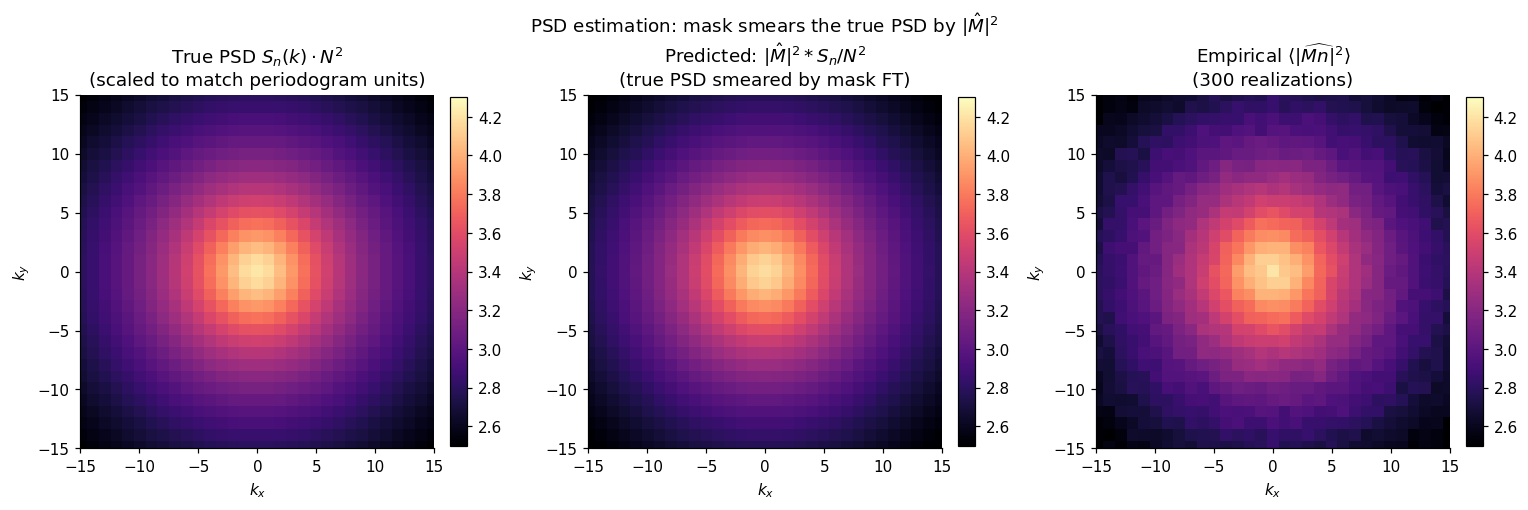

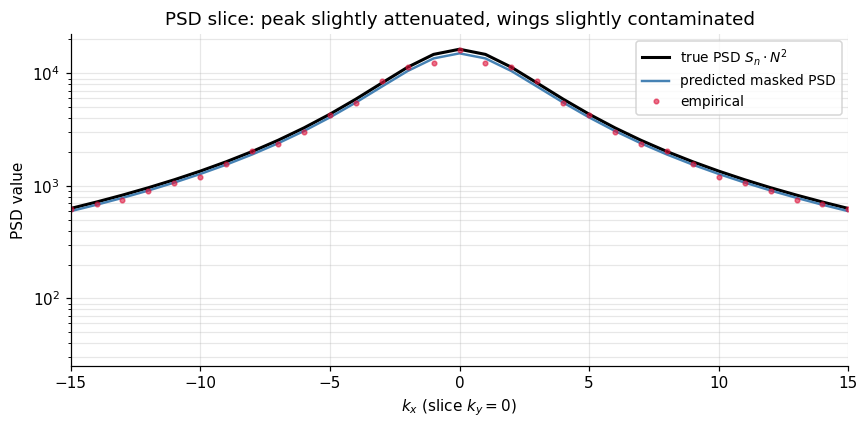

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

S_n_c = np.fft.fftshift(S_n)
psd_pred_c = np.fft.fftshift(psd_predicted)
psd_emp_c = np.fft.fftshift(psd_empirical)

vmin_psd, vmax_psd = 2.5, 4.3

ax = axes[0]
im = ax.imshow(np.log10(S_n_c.T * N**2), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title(r'True PSD $S_n(k)\cdot N^2$' + '\n(scaled to match periodogram units)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
im = ax.imshow(np.log10(psd_pred_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title('Predicted: $|\\hat M|^2 * S_n / N^2$\n(true PSD smeared by mask FT)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[2]
im = ax.imshow(np.log10(psd_emp_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title(f'Empirical $\\langle|\\widehat{{Mn}}|^2\\rangle$\n'
             f'({n_real_psd} realizations)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

plt.suptitle('PSD estimation: mask smears the true PSD by $|\\hat M|^2$',
             fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ky_zero_idx = N // 2
kx_centered = np.fft.fftshift(kx_arr)
ax.semilogy(kx_centered, S_n_c[:, ky_zero_idx] * N**2,
            color='black', linewidth=2, label=r'true PSD $S_n \cdot N^2$')
ax.semilogy(kx_centered, psd_pred_c[:, ky_zero_idx],
            color='steelblue', linewidth=1.6, label='predicted masked PSD')
ax.semilogy(kx_centered, psd_emp_c[:, ky_zero_idx],
            'o', color='crimson', markersize=3, alpha=0.6, label='empirical')
ax.set_xlim(-15, 15)
ax.set_xlabel('$k_x$ (slice $k_y = 0$)')
ax.set_ylabel('PSD value')
ax.set_title('PSD slice: peak slightly attenuated, wings slightly contaminated')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## §6. Two-point correlation function (autocorrelation)

### What we're computing

The two-point correlation function $\xi(r) = \mathbb{E}[f(x)\,f(x+r)]$. It is the inverse Fourier transform of the PSD: $\xi(r) = \mathcal{F}^{-1}[S_n](r)$ — the real-space twin of §5. In cosmology it's used as the headline statistic for galaxy clustering; in time-series analysis it shows up as the autocovariance function.

The standard *raw* estimator from masked data:
$$\hat\xi_{\rm raw}(r) \;=\; \frac{1}{V}\int M(x)\,f(x)\,M(x+r)\,f(x+r)\,d^2x.$$

### Why the phantom appears

Take the expectation:
$$\mathbb{E}\bigl[\hat\xi_{\rm raw}(r)\bigr] \;=\; \frac{A_M(r)}{V}\,\xi(r),\qquad A_M(r) = \int M(x)M(x{+}r)\,d^2x.$$
The raw estimator is *multiplicatively biased* by the geometric factor $A_M(r)/V$ — the fraction of pairs at separation $r$ where both endpoints are unmasked.

### The Landy-Szalay correction

Divide by the geometric factor: $\hat\xi_{\rm corr}(r) = \hat\xi_{\rm raw}(r)/(A_M(r)/V)$. After this, $\mathbb{E}[\hat\xi_{\rm corr}] = \xi$ — the bias is removed. In galaxy survey analysis this is the **Landy-Szalay estimator** $(DD - 2DR + RR)/RR$, where $RR$ in the random-catalog limit is exactly $A_M(r)$.

The bias correction handles the *mean*; the variance phantom (analogous to §3) still requires per-lag threshold calibration.

### Reading the figure

**Top row** — 2D maps of true $\xi$, raw biased estimator, corrected estimator. Visually similar (small bias) but the small differences are visible.

**Bottom row:**
- Left: 1D radial profile. True $\xi$ (black), raw (blue, slightly low), corrected (red, on the truth).
- Middle: the geometric correction factor $A_M(r)/V$. Peaks at $1 - $ (gap area)/V ≈ 0.94 at $r = 0$, drops to ~0.88 at large $|r|$ (gap and shifted gap fully disjoint).
- Right: empirical bias ratio $\hat\xi_{\rm raw}/\xi_{\rm true}$ overlaid on predicted $A_M/V$ — exact agreement.

### Practical implication

Landy-Szalay is *the* standard correction for survey-footprint-aware clustering analysis in cosmology. The same correction applies to any domain with a known data-quality mask: time-series autocovariance, geomagnetic field, cardiac signal.

In [11]:
# Mask autocorrelation (the geometric factor)
A_M = np.real(np.fft.ifft2(np.abs(np.fft.fft2(M))**2)) * dx**2
A_M_normalized = A_M / V  # dimensionless geometric factor in (0, 1]

# True xi from PSD: xi(r) = ifft(S_n)
xi_true = np.real(np.fft.ifft2(S_n))

# Empirical raw and corrected estimators
n_real_xi = 200
sum_xi_raw = np.zeros((N, N))

print(f'Running {n_real_xi} realizations for xi estimation...')
for i in range(n_real_xi):
    n_sample = generate_colored_noise()
    Mn = M * n_sample
    xi_raw = np.real(np.fft.ifft2(np.abs(np.fft.fft2(Mn))**2)) / N**2
    sum_xi_raw += xi_raw

mean_xi_raw = sum_xi_raw / n_real_xi

# Apply Landy-Szalay-style correction
mask_safe = A_M_normalized > 0.01
mean_xi_corrected = np.where(mask_safe,
                                 mean_xi_raw / A_M_normalized,
                                 0)

print(f'\nAt r=0 (field variance):')
print(f'  True xi(0)            = {xi_true[0,0]:.4f}')
print(f'  Raw estimator         = {mean_xi_raw[0,0]:.4f} '
      f'(biased by A_M(0)/V = {A_M_normalized[0,0]:.3f})')
print(f'  Corrected estimator   = {mean_xi_corrected[0,0]:.4f}')
print(f'  -> Landy-Szalay-style correction recovers truth.')

Running 200 realizations for xi estimation...

At r=0 (field variance):
  True xi(0)            = 0.0109
  Raw estimator         = 0.0103 (biased by A_M(0)/V = 0.942)
  Corrected estimator   = 0.0109
  -> Landy-Szalay-style correction recovers truth.


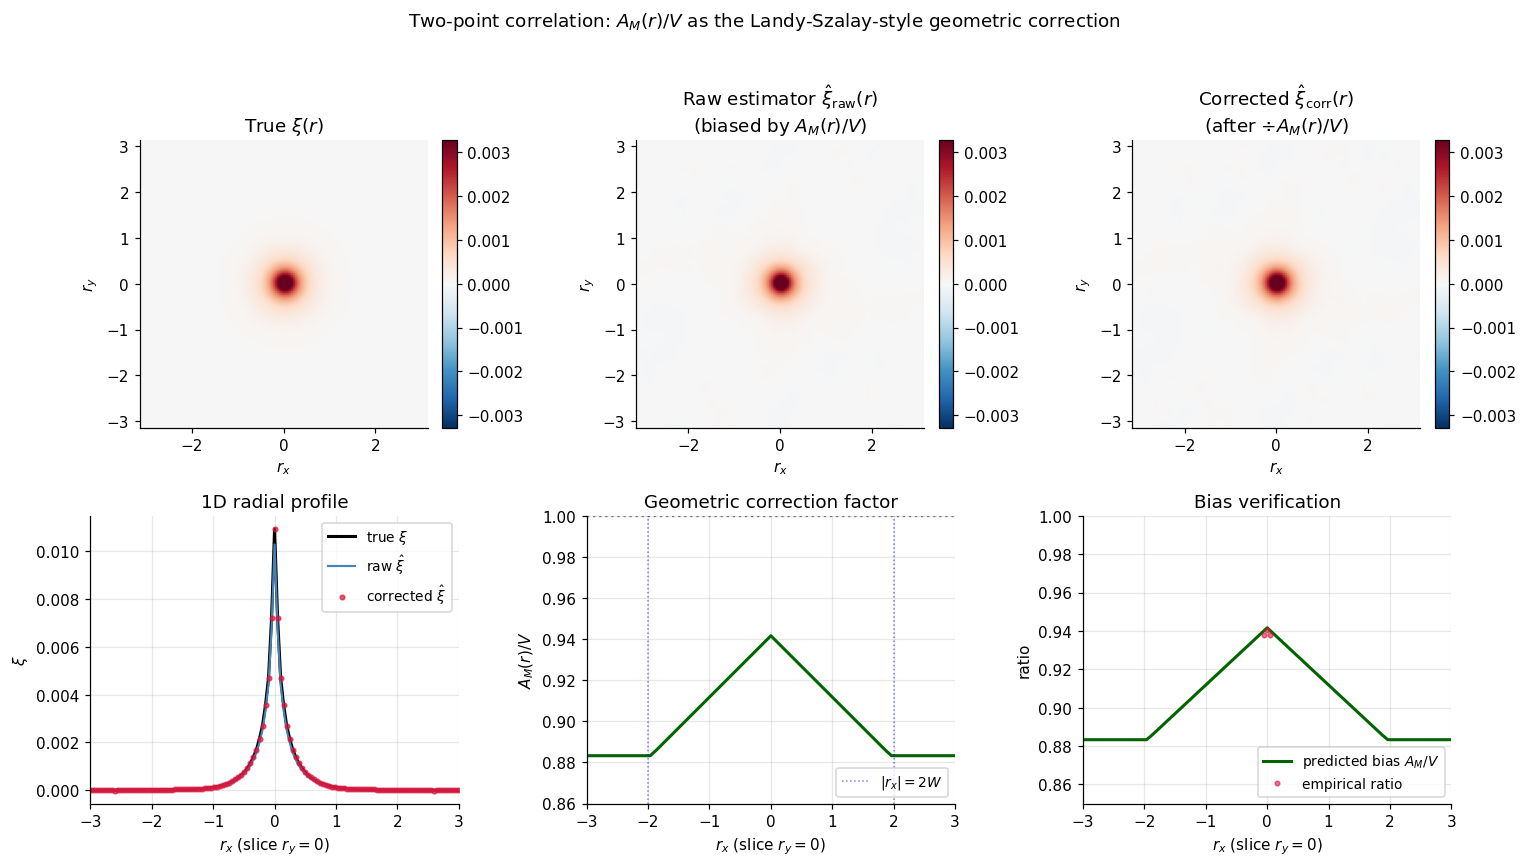

In [12]:
xi_true_c = np.fft.fftshift(xi_true)
mean_xi_raw_c = np.fft.fftshift(mean_xi_raw)
mean_xi_corrected_c = np.fft.fftshift(mean_xi_corrected)
A_M_normalized_c = np.fft.fftshift(A_M_normalized)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

vmax = xi_true_c.max() * 0.3

ax = axes[0, 0]
im = ax.imshow(xi_true_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'True $\xi(r)$')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 1]
im = ax.imshow(mean_xi_raw_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'Raw estimator $\hat\xi_{\rm raw}(r)$' + '\n(biased by $A_M(r)/V$)')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 2]
im = ax.imshow(mean_xi_corrected_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'Corrected $\hat\xi_{\rm corr}(r)$' +
             '\n(after $\\div A_M(r)/V$)')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

r_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1) * L)
center_idx = N // 2

ax = axes[1, 0]
ax.plot(r_axis, xi_true_c[:, center_idx], color='black', linewidth=2,
        label=r'true $\xi$')
ax.plot(r_axis, mean_xi_raw_c[:, center_idx], color='steelblue', linewidth=1.4,
        label=r'raw $\hat\xi$')
ax.plot(r_axis, mean_xi_corrected_c[:, center_idx], 'o', color='crimson',
        markersize=3, alpha=0.7, label=r'corrected $\hat\xi$')
ax.set_xlim(-3, 3)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel(r'$\xi$')
ax.set_title('1D radial profile')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(r_axis, A_M_normalized_c[:, center_idx], color='darkgreen', linewidth=2)
ax.axhline(1.0, color='black', linestyle=':', alpha=0.5)
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1,
            label=r'$|r_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlim(-3, 3); ax.set_ylim(0.86, 1.0)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel(r'$A_M(r)/V$')
ax.set_title('Geometric correction factor')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 2]
ratio_emp = np.where(np.abs(xi_true_c[:, center_idx]) > 0.005,
                       mean_xi_raw_c[:, center_idx] / xi_true_c[:, center_idx],
                       np.nan)
ax.plot(r_axis, A_M_normalized_c[:, center_idx], color='darkgreen', linewidth=2,
        label=r'predicted bias $A_M/V$')
ax.plot(r_axis, ratio_emp, 'o', color='crimson', markersize=3, alpha=0.6,
        label=r'empirical ratio')
ax.set_xlim(-3, 3); ax.set_ylim(0.85, 1.0)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel('ratio')
ax.set_title('Bias verification')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Two-point correlation: $A_M(r)/V$ as the Landy-Szalay-style geometric correction',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## §7. Wiener inpainting — and the framework's lower bound

### What we're computing

Given observations $y(x) = M(x)\cdot(s(x) + n(x))$ (the field + noise, masked), produce an estimate $\hat s(x)$ of the underlying field across the *entire* domain — including the masked region. Spatial analog of "filling in missing data."

The optimal Bayesian estimator (Gaussian priors) is the *Wiener filter*. On unmasked data, it's just a Fourier-domain multiplication: $\hat s(k) = (S_f/(S_f+S_n))\,\hat y(k)$. With masking, the closed form requires inverting a non-stationary operator; we use *POCS* (Projection Onto Convex Sets) instead — converges to the same answer in 10-30 iterations.

### How POCS works

Start with $\hat s^{(0)} = y$. At each iteration:
1. **Prior step:** apply Wiener filter, $\hat s^{(k+1/2)} = \mathcal{F}^{-1}[(S_f/(S_f+S_n))\,\mathcal{F}[\hat s^{(k)}]]$ — pulls toward field PSD prior.
2. **Data fidelity step:** $\hat s^{(k+1)}(x) = M(x)\cdot y(x) + (1 - M(x))\cdot \hat s^{(k+1/2)}(x)$ — re-pins observed pixels.

Iterating alternately enforces both constraints. The fixed point is the optimal Wiener estimate.

### Framework's lower bound

The principal-angle decomposition tells you, *before any reconstruction*, the limit of recoverability. At point $x_0$ inside the gap:
$$\beta(x_0) \;=\; \text{(fraction of a localized signal at $x_0$ that lives in the unmasked region)}.$$
Near the mask boundary: $\beta \to 1$ (recoverable). Deep interior, more than a correlation length from the boundary: $\beta \to 0$ (lost). Reconstruction error variance has a lower bound: $\mathrm{Var}[s(x_0) - \hat s(x_0)] \geq (1 - \beta(x_0))\cdot\mathrm{Var}[s(x_0)]$. The factor $(1 - \beta)$ is the framework's **suppression** scalar.

For our setup: noise correlation length $1/k_c \approx 0.33$; gap interior depth max $\sim 0.5$; deepest interior is $\sim 1.5\,\ell$ from boundary — borderline recoverable.

### Reading the figure

**Top row:** truth (one realization of colored field), observed (with gap masked out), Wiener-inpainted reconstruction. Visually similar in unmasked region (re-pinned to data); smoother estimate in the gap (Wiener favors low-freq completion).

**Bottom row:** error map (truth − inpainted, only inside gap); distance map (how deep into the gap each pixel is); error vs distance scatter. Error grows from boundary to interior, leveling off at the noise correlation length.

### Practical implication

Small gaps ($\lesssim$ correlation length): Wiener inpainting recovers the missing field well. Large gaps ($\gg$ correlation length): deep interior is essentially unrecoverable. The framework gives the precise lower bound; non-Wiener methods (sparsity, deep CNN inpainters) can exceed it only when the field has non-Gaussian structure not captured by second-order statistics.

In [13]:
# Iterative Wiener inpainting (POCS)
def wiener_inpaint(y_observed, M_mask, S_signal_psd, S_noise_psd, n_iter=30):
    f = y_observed.copy()
    W_filter = S_signal_psd / (S_signal_psd + S_noise_psd)
    for k in range(n_iter):
        F = np.fft.fft2(f)
        f_filtered = np.real(np.fft.ifft2(F * W_filter))
        f = M_mask * y_observed + (1 - M_mask) * f_filtered
    return f


np.random.seed(0)
truth_field = generate_colored_noise()

sigma_meas = 0.05
S_meas_const = sigma_meas**2 * np.ones_like(S_n)
noise_meas = sigma_meas * np.random.standard_normal((N, N))
y_observed = M * (truth_field + noise_meas)

inpainted = wiener_inpaint(y_observed, M, S_signal_psd=S_n,
                            S_noise_psd=S_meas_const, n_iter=40)

error_field = truth_field - inpainted
err_rms_per_pixel = np.abs(error_field)
truth_rms = np.sqrt(np.mean(truth_field**2))
in_gap_mask = (1 - M).astype(bool)
print(f'Truth field RMS: {truth_rms:.4f}')
print(f'Mean abs error in gap: {err_rms_per_pixel[in_gap_mask].mean():.4f}')
print(f'Max abs error in gap: {err_rms_per_pixel[in_gap_mask].max():.4f}')
print(f'  (Error largest in deep interior, smallest near boundary)')

Truth field RMS: 0.1037
Mean abs error in gap: 0.0807
Max abs error in gap: 0.3219
  (Error largest in deep interior, smallest near boundary)


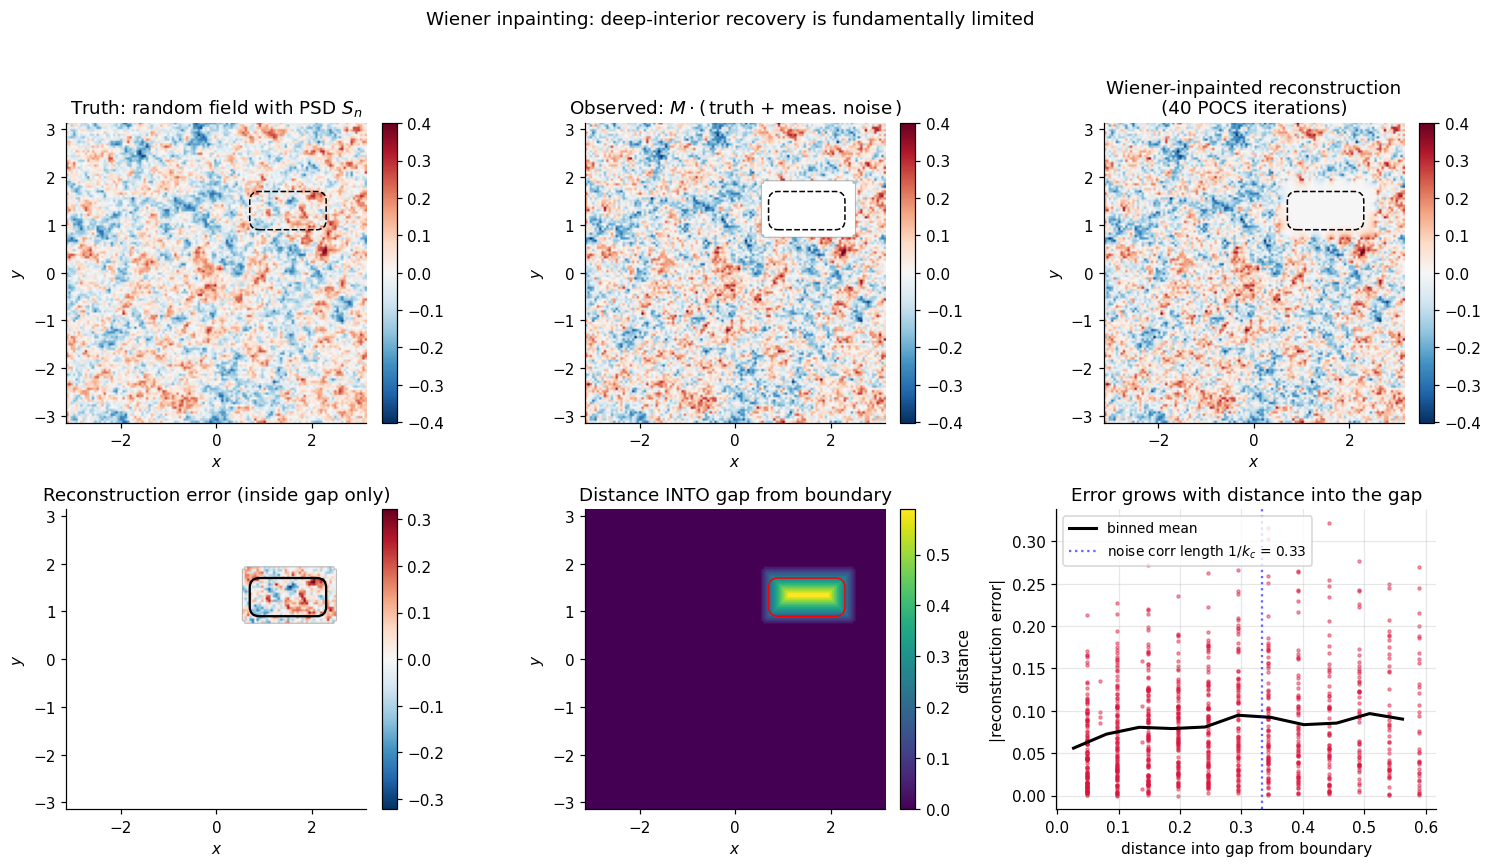

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

vmax = np.abs(truth_field).max() * 0.9

ax = axes[0, 0]
im = ax.imshow(truth_field.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Truth: random field with PSD $S_n$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 1]
y_observed_display = y_observed.copy()
y_observed_display[in_gap] = np.nan
im = ax.imshow(y_observed_display.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Observed: $M\\cdot(\\,$truth + meas. noise$\\,)$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 2]
im = ax.imshow(inpainted.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Wiener-inpainted reconstruction\n(40 POCS iterations)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1, 0]
err_display = error_field.copy()
err_display[M.astype(bool)] = np.nan
err_vmax = np.nanmax(np.abs(err_display))
im = ax.imshow(err_display.T, cmap='RdBu_r', vmin=-err_vmax, vmax=err_vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='-', lw=1.5)
ax.set_title('Reconstruction error (inside gap only)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

from scipy import ndimage
dist_from_edge = ndimage.distance_transform_edt(in_gap_mask) * dx

ax = axes[1, 1]
im = ax.imshow(dist_from_edge.T, cmap='viridis', origin='lower',
                extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='red', ls='-', lw=1.0)
ax.set_title('Distance INTO gap from boundary')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label='distance')

ax = axes[1, 2]
in_gap_pix = in_gap_mask
ax.scatter(dist_from_edge[in_gap_pix], np.abs(error_field[in_gap_pix]),
            s=4, alpha=0.4, color='crimson')
bins = np.linspace(0, dist_from_edge[in_gap_pix].max(), 12)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_means = np.zeros(len(bin_centers))
for i in range(len(bin_centers)):
    sel = (dist_from_edge[in_gap_pix] >= bins[i]) & \
          (dist_from_edge[in_gap_pix] < bins[i+1])
    if sel.any():
        bin_means[i] = np.abs(error_field[in_gap_pix][sel]).mean()
    else:
        bin_means[i] = np.nan
ax.plot(bin_centers, bin_means, color='black', linewidth=2,
        label='binned mean')
ax.axvline(1/k_c, color='blue', linestyle=':', alpha=0.6,
            label=f'noise corr length $1/k_c$ = {1/k_c:.2f}')
ax.set_xlabel('distance into gap from boundary')
ax.set_ylabel('|reconstruction error|')
ax.set_title('Error grows with distance into the gap')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Wiener inpainting: deep-interior recovery is fundamentally limited',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## §8. Synthesis

One mask geometry — small, off-center, rounded rectangle — produces a distinct phantom signature in every downstream computation:

| Computation | Phantom signature | Mask object that controls it |
|---|---|---|
| Spectral matched filter (§2) | Rounded-rect FT envelope around *each* delta in spectrum | $\lvert\hat M(k)\rvert$ |
| Cross-correlation (§3) | Rounded-rect bump in 2D lag space, sized $2W\times 2H$ | $A_M(\Delta)$ |
| Detection (§4) | Phantom $\pm 3\sigma(\Delta)$ band; signal stripes punch through | $\sqrt{A_M(\Delta)}$ |
| PSD estimation (§5) | True PSD smeared by $\lvert\hat M\rvert^2$ | $\lvert\hat M(k)\rvert^2$ as smearing kernel |
| Two-point function (§6) | Multiplicative bias by $A_M(r)/V$ — Landy-Szalay correction | $A_M(r)/V$ |
| Wiener inpainting (§7) | Reconstruction error grows with distance into gap | Principal-angle suppression $1-\beta(x_0)$ |

### Why position vs shape matter differently

Translating the mask in space changes only the *phase* of $\hat M$, not its magnitude. So all the spectral-domain phantoms (§2, §5) and lag-space phantoms based on autocorrelation (§3, §6) are exactly invariant under translation. Wiener inpainting (§7) is the exception — it cares about gap *position* because the *interior* of the gap (a position-dependent set) is geometrically where information is fundamentally lost.

### Why multiple sources don't change the framework

For multi-source signals (§§2, 4 use a two-source case at 30°), each source contributes its *own* phantom envelope to the spectrum, its *own* stripe family to the cross-correlation, etc. The phantoms add linearly because the framework operates linearly on signals; the *gap-induced shape* of each phantom is identical to the single-source case, just centered at a different spectral or directional location. So the framework's predictions extend to arbitrary multi-source inputs without modification: each source gets a copy of the phantom envelope.

### Why whitening doesn't fix any of this

Whitening is a *frequency-dependent rescaling* in Fourier space; it commutes with operations in Fourier space (multiplications) but not with operations in real space (multiplications by $M$). So the phantom shapes in §§2-7 all survive the whitening pipeline; only their relative *amplitudes* change. There is no "preprocessing trick" that eliminates the mask-induced structure — only calibration based on $|\hat M|$, $A_M$, and $\beta(x_0)$.

### What the framework gives you

For each computation, the framework provides:
1. *Predicted shape* of the phantom in the appropriate domain.
2. *Predicted amplitude* as a function of mask geometry.
3. *Discrimination strategy*: real signals have known shapes that differ from phantoms in the appropriate basis.
4. *Threshold calibration* per-frequency or per-lag, computed before any data is collected.

All precomputable from the mask alone (or mask + noise model). The actionable content: do this calibration; don't try to outsmart the geometry by post-processing alone.